# Lab 5. VLM. CLIP. BLIP-2. LoRA.

So previosuly we've talked about generative models and theoretical basis. The idea that stands behind them usually is associated with aprroximating our posterior distribution by likelihood in some parametric system.

So we've gone through several architectural approaches - VAE, GAN, Diffusion. Today let's switch to multi-moodal architectures.

**Visual Language Models (VLMs)** are multimodal AI systems that combine computer vision and natural language processing to interpret, reason about, and **generate** text based on both image and text inputs.



## CLIP: Contrastive Language Image Pre-training
https://arxiv.org/pdf/2103.00020

Main idea - **contrastive representation learning** in bimodal space. The goal of contrastive representation learning is to learn such an embedding space in which similar sample pairs stay close to each other while dissimilar ones are far apart.

<img src="https://i.postimg.cc/ht46h8t1/contrastive-repr-learning.webp" width="600" height="400">


In a standard contrastive learning approach you give the model examples of the form (anchor, positive, negative), where anchor is an image from one class, say a dog, positive is an alternative image from the same class, a dog, and negative is an image of another class, say a bird. You then embed the images and you train the model in such a way that the distance between the two embeddings for the same class (the dog), distance(anchor, positive), gets minimised and the distance between the two embeddings of different class, (the dog and bird), distance(anchor, negative), gets maximised. This encourages the model to output very similar embeddings for the same objects and dissimilar embeddings for different objects.


CLIP's focus was about making a task-agnostic model for a zero-shot transfer learning. At the core of this approach is the idea of learning perception from supervision contained in **natural language**.

For a purpose of NLP supervision authors constructed a new dataset of 400 million (image, text) pairs collected form a variety of publicly available sources on the Internet. Using a contrastive learning, objective was to train the model to **align images and text in a shared embedding space**.

<img src="https://i.postimg.cc/7ZPdb1Zg/CLIP.png" width="850" height="400">

Let's go through an idea behind this model:


- Basically CLIP is composed of two separate models for processing text and images (text encoder (Transforemr) and image encoder (ResNet or Transformer)).
- Each model produces a vector length of 512
- Idea is that representations each of vectors should be similar

How to achieve this? We need to provide some **new training method**. Authors proposed the following method:

1. Take a batch of text-image pairs.
- Each image in the batch is processed by the image encoder (e.g., a Vision Transformer or ResNet model) to generate an image embedding vector.
- Each corresponding text description is tokenized and processed by the text encoder (e.g., a Transformer-based language model) to generate a text embedding vector.
2. The output vectors from both encoders are projected into a single, shared, fixed-size embedding space (e.g., 512 dimensions) using a simple linear layer. These embeddings are also normalized to a unit norm (length of 1) - **shared embedding space**
3. **A similarity matrix** is created by calculating the cosine similarity (which is a dot product for normalized vectors) between every image embedding and every text embedding in the batch. The resulting matrix has $NxN$ potential similarities.

<img src="https://i.postimg.cc/L84whk8f/CLIP_algo.png" width="400" height="400">


The intuition behind CLIP's training can be briefly summarized using the following GIF. During training, the images and the captions that describe them are put close in the vector space, while the non-matching images (or captions) are pushed away.

<img src="https://i.postimg.cc/HkWRj0k7/CLIP_training.gif" width="600" height="400">

**Shared and aligned** embedding space for both types of embeddings - core of our attention.

How does it look like from the optimization perspective? **InfoNCE** or Information Noise-Contrastive Estimation.

1. Images and text are passed through encoders to generate vectors. These vectors are $L2-normalized$ to form matrix of similarities which scaled up by a learnable temperature parameter $\tau$
2. For each row (image) and column (text) in the similarity matrix, a softmax is applied, followed by cross-entropy loss against the true matching pairs (the diagonal)

$L_{i->t} = -log\frac{\exp(sim(I_{i}, T_{i})/\tau)}{\sum_{j=1}^{T}\exp(sim(I_{i}, T_{j})/\tau)}$

Final loss: $\frac{1}{2}L_{i->t}+L_{t->i}$

3. After calculating the InfoNCE loss in a CLIP (Contrastive Language-Image Pre-training) model, the weights updated during backpropagation are those of the entire dual-encoder architecture, which includes
- image encoder
- text encoder
- projection heads
- logit scale parameter

Because it uses softmax over a batch, it treats the problem as a classification task where the model learns to pick the correct pair out of N candidates.

Remember that CLIP is a task-agnostic approach which only constructs aligned embeddings making an architecture for a further zero-shot classification applications or some other easy-to-go tasks.

BUT: Current pre-training architectures often rely on **large-scale training**, which not only requires significant resources but also does not transfer well to every downstream task due to their diverse nature.

## BLIP - 2: Bootstrapping Language-Image Pre-training with Frozen Image Encoders and Large Language Models

https://arxiv.org/pdf/2301.12597

<img src="https://i.postimg.cc/X7KZWzxB/BLIP-2-arch.png" width="475" height="350">

Let's dive into some details step-by-step:

1. We DON'T touch Image and Encoder and LLM part keeping them frozen, as ViT provides good image representations while LLM offer strong language generation and zero-shot transfer abilities. But how to connect them?

2.  Authors proposed something called a Querying Transformer (**Q-Former** - picture below).

### Q-Former

<img src="https://i.postimg.cc/SRzPB8hj/BLIP_2.jpg" width="775" height="350">

It consists of two Transformer submodules where image layers consist of cross-attention while text layers don't have it.  Image part also gets an input in a form of **query tokens** that are trainable and can interact with text tokens (**through different masking methods**).

<img src="https://i.postimg.cc/mrvCKxZM/BLIP-2-mask.png" width="950" height="350">



- In the first pre-training stage, it performs vision-language representation learning which enforces the Q-Former to learn visual representation most relevant to the text
- In the second pre-training stage, we perform vision-to-language generative learning by connecting the output of the Q-Former to a frozen LLM, and trains the Q-Former such that its output visual representation can be interpreted by the LLM
- Between self-attention block you might notice a masked attention which is applied depending upon a task that we want to complete
- Interaction between image encoder and Q-Former happen through a cross-attention
- Query tokens basically interact with image tokens and transmitting information to text tokens by self-attention layers
- After that obtained query tokens goes to fully-connected layer to make a reshape before being digested into LLM

Authors provided optimization of three pre-training objectives that share the same input format and model parameters.  Each objective employs a different attention masking strategy between queries and text to control their interaction.

- **Image-Text Contrastive Learning** - learns to align
image representation and text representation such that their
mutual information is maximized. Image-Text Contrastive Learning aims to align image and text representations in **a shared embedding space**. Given an image of I and text T, the model is trained to increase the similarity between matching pairs and decrease it between mismatched ones.It achieves so by contrasting the image-text similarity of a positive pair against those
of negative pairs.

<img src="https://i.postimg.cc/pdHbjGYG/ITC-loss.webp" width="300" height="50">

where $q_{I}$​ and $q_{T}$​ are the aggregated query features for image and text respectively, sim(⋅,⋅) denotes cosine similarity, and τ is a learnable temperature parameter.


- **Image Grounded Text Generation** - loss trains the
Q-Former to generate texts, given input images as the condition. Remember that there is no direct interaction between image encoder and text encoder. Therefore, the queries are forced to extract visual features that capture all the information about the text. We employ a multimodal causal self-attention mask to control query-text interaction. Our final goal is to generate image caption and calculate loss.

<img src="https://i.postimg.cc/LXbVYVJ0/IGT-loss.webp" width="300" height="80">

Here, $w_{t}$ is the target token at position t, and the model is conditioned on both the preceding tokens and the image. During IGT training, we use a special [DEC] token to start generation, and apply causal masking so that future tokens are not visible. The queries are also prevented from attending to the text stream.

- **Image-Text Matching** - In this loss each token can see each other(bidirectional self-attention) and by using output from image submodule, which is our query embeddings, calculate proabilities of "match - no match" for each token from text tokens. Basically it asks question "does this image actually match this question?".

<img src="https://i.postimg.cc/3wQVWYsk/ITM-loss.webp" width="400" height="30">



Significant progress in solved tasks:

- visual question answering
- image captioning
- image-text retrieval







## Practical part

### LoRA

LoRA introduces a low-rank decomposition, significantly reducing the number of trainable parameters. This is achieved by **learning two smaller vectors**, which, when multiplied, form a low-rank matrix. This matrix is then used to adjust the original model weights (optional) without altering their structure. Because the number of parameters trained is much lower than in traditional fine-tuning, LoRA requires less computational power and memory. Once trained, these additional LoRA values are simply added to the original model weights during inference, ensuring that the adaptation does not introduce extra computational overhead.

Output = $W_{0}x + \Delta Wx = W_{0}x + \frac{α}{r} BAx$, where

- $W_{0}$ - The original frozen, pre-trained weight matrix
- **BA** - The product of the low-rank trainable matrices

<img src="https://i.postimg.cc/0jHRnCx4/lora.png" width="450" height="200">

- $\frac{α}{r}$ - scaling factor (where α is a constant and r is the rank) applied to the low-rank matrices to stabilize training
- After training you can keep output in the form of $W_{0}x + BAx$ or add it to the weights

$W_{final} = W_{0} + BA$



First let's install **unsloth** library, which will help us to make the process of LoRA training much easier. We will follow the process according to the documentation provided by authors in their repository:

https://github.com/unslothai/unsloth

In [1]:
!pip install unsloth

Import libraries...

In [2]:
from datasets import load_dataset
from transformers import TextStreamer
from unsloth import FastVisionModel
import torch

/tmp/ipython-input-2406943912.py:3: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastVisionModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


We will make a ste-by-step low-rank adaptation for a small visual transformer model using publicly available dataset.

The training set contains 1,978 samples, while the evaluation set consists of 327 samples. Each sample includes:
- An image (e.g., CT scan, radiograph)
- A textual diagnosis describing the condition

In [3]:
dataset_train = load_dataset("unsloth/Radiology_mini", split = "train")
dataset_eval = load_dataset("unsloth/Radiology_mini", split = "test")

README.md:   0%|          | 0.00/610 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/481M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/79.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1978 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/327 [00:00<?, ? examples/s]

To train a LoRA for multimodal tasks, we need to format the dataset accordingly. The training pipeline expects the dataset in the following structured conversational format, where the user provides an image and a text prompt, and the assistant generates a response:

In [4]:
instruction = "You are an expert radiographer. Describe accurately what you see in this image."

def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["caption"]} ]
        },
    ]
    return { "messages" : conversation }
pass

In [5]:
converted_dataset_train = [convert_to_conversation(sample) for sample in dataset_train]
converted_dataset_eval = [convert_to_conversation(sample) for sample in dataset_eval]

Let's import our model, this time it will be a very small version of Qwen2 visual language model.

In [6]:
model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen2-VL-2B-Instruct",
    load_in_4bit = False,
    use_gradient_checkpointing = "unsloth",
)

==((====))==  Unsloth 2026.2.1: Fast Qwen2_Vl patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


model.safetensors:   0%|          | 0.00/4.42G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/572 [00:00<?, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

Let's take a look on the random picture...

In [7]:
image = dataset_eval[20]["image"]

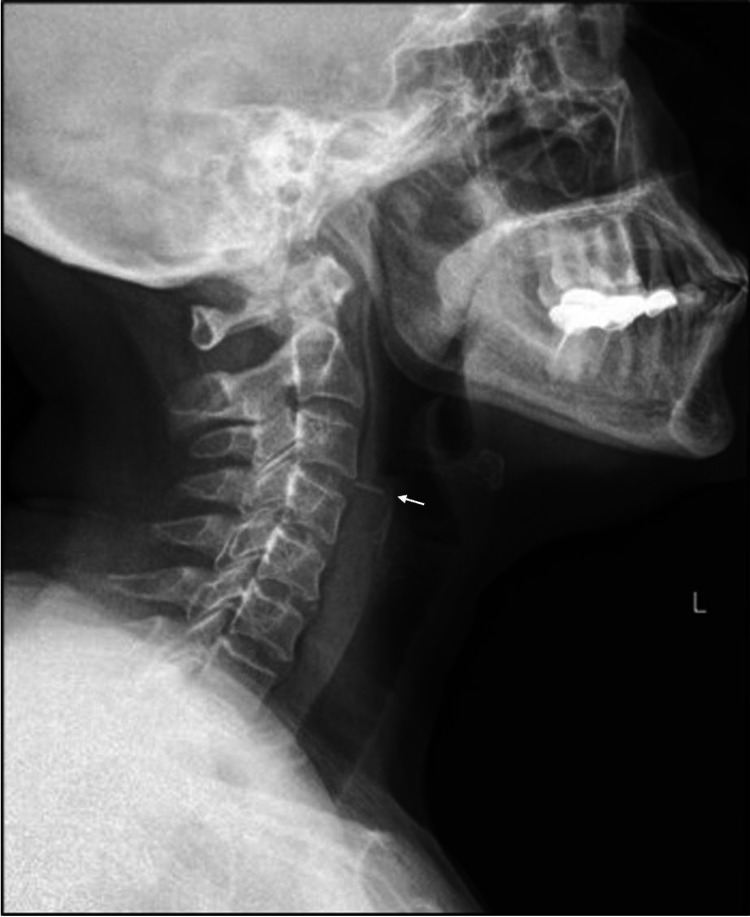

In [8]:
image

In [9]:
dataset_eval[20]["caption"]

'A lateral neck soft tissue x-ray showing a foreign body (arrow) in the hypopharynx with a linear radiolucency in the retropharyngeal space representing free air'

In [10]:

instruction = "You are an expert radiographer. Describe accurately what you see in this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

text_streamer = TextStreamer(tokenizer, skip_prompt = True)
prediction = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 0.01, min_p = 0.1)

This is a lateral radiograph of the neck and upper thoracic spine. The image shows the following:

1. **Cervical Spine**: The cervical spine is visible, consisting of multiple vertebrae. The vertebrae are seen as curved, tubular structures with a vertebral body at the center. The vertebrae are connected by intervertebral discs, which are visible as rounded, spongy structures between the vertebrae.

2. **Cervical Spine Alignment**: The alignment of the cervical spine is normal, with the vertebrae appearing to be in a straight line. There are no obvious


Not Bad for such small model. But what will a bigger one will say using the same prompt?

**GPTo3**:

Linear radiopaque foreign body within the prevertebral soft tissues at approximately C4–C5 level, suspicious for an ingested sharp foreign body (e.g., fish bone). Background cervical spondylosis noted.
If clinically indicated, correlation with symptoms and possible further evaluation (e.g., CT neck) would be appropriate.

Definitely GPT defined that something is wrong, while our smaller indicated no deviations. **What's the problem with such evaluation?**

Ok let's continue our preparation of LoRA.
First, let's define LoRA parameters. The following code shows the hyperparameters directly related to the LoRA network.

In [11]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=False,  # Set to False to freeze vision layers
    finetune_language_layers=True, # Set to True to finetune language layers
    finetune_attention_modules=True, # Set to True to finetune attention layers
    finetune_mlp_modules=True, # Set to True to finetune MLP layers
    r=16,  # A higher value increases accuracy but may risk overfitting
    lora_alpha=16,  # Recommended alpha value (usually matches r)
    lora_dropout=0.05,
    bias="none",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Unsloth: Making `model.base_model.model.model.language_model` require gradients


Be careful what parameters you choose to modify. in this example we have opted to train only the language model component while keeping the vision-related components frozen.

The fewer parameters we modify, the better, as excessive changes could lead to overfitting, potentially impairing the model’s performance. Furthermore, as we will observe in subsequent tests, while the vision model can understand the images, it struggles with diagnostic accuracy. Therefore, we will focus on improving the model’s text comprehension.

In [12]:
from unsloth import is_bf16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
from transformers import TrainerCallback

FastVisionModel.for_training(model)

args = SFTConfig(
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    warmup_steps=5,
    num_train_epochs=15,
    learning_rate=2e-4,
    fp16=not is_bf16_supported(),
    bf16=is_bf16_supported(),
    optim="adamw_8bit",
    eval_steps=1,
    weight_decay=0.01,
    lr_scheduler_type="linear",
    seed=3407,
    output_dir="outputs",
    report_to="none",
    eval_strategy="epoch",
    save_strategy="epoch",
    metric_for_best_model="loss",
    load_best_model_at_end=True,
    greater_is_better=False,
    log_level="info",
    remove_unused_columns=False,
    dataset_text_field="",
    dataset_kwargs={"skip_prepare_dataset": True},
    dataset_num_proc=4,
    max_seq_length=2048,
)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset = converted_dataset_train,
    eval_dataset=converted_dataset_eval,
    args = args
)

Unsloth: Model does not have a default image size - using 512


Using auto half precision backend


In [ ]:
trainer.train()

skipped Embedding(151936, 1536, padding_idx=151654): 222.5625M params
skipped: 222.5625M params
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,978 | Num Epochs = 15 | Total steps = 3,720
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 2,227,450,368 (0.83% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Epoch,Training Loss,Validation Loss
1,1.446800,1.087555
2,0.964700,1.097347
3,0.861400,1.169268
4,0.511700,1.279453



***** Running Evaluation *****
  Num examples = 327
  Batch size = 4
Unsloth: Not an error, but Qwen2VLForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient
Saving model checkpoint to outputs/checkpoint-248
loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--unsloth--Qwen2-VL-2B-Instruct/snapshots/2aa5abe967182dd58a330ae79664772c263baaa8/config.json
Model config Qwen2VLConfig {
  "architectures": [
    "Qwen2VLForConditionalGeneration"
  ],
  "attention_dropout": 0.0,
  "dtype": "bfloat16",
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 1536,
  "image_token_id": 151655,
  "initializer_range": 0.02,
  "intermediate_size": 8960,
  "max_position_embeddings": 32768,
  "max_window_layers": 28,
  "model_type": "qwen2_vl",
  "num_attention_heads": 12,
  "num_hidden_layers": 28,
  "n

Epoch,Training Loss,Validation Loss
1,1.446800,1.087555
2,0.964700,1.097347
3,0.861400,1.169268
4,0.511700,1.279453


You might notice that there is no inference function. It is up to you to find it during your homework.

# Homework (you are free to choose)

You have to make LoRA training for a model you choose. You can use models from library whether you want as well as a dataset. But remember that you have to find a dataset with images paired with captions respectively as we did during the lab.

Requirements:

1. You should provide several examples with image and its caption. Compare results your model with caption by cosine similarity.
2. Than make LoRA training.
3. After training, use your trained model and show some improvements by cosine similarity.
4. If such metrics is considered as non-relevant - write down your exlplanation and choose a new assessment method (e.g. it could be using cosine similarity between a better and bigger model with a model after a fine-tuning procedure)

Don't take a big model as it will take too much time to complete training.

**OR**

You have to choose architecture with text-to-image principle and fine-tune it to your task.

Requirements:

* Find an architecture, if CLIP - it should be a different dataset
* Find a dataset adapted for text-to-image task
* Prepare a dataset to fine-tune your model accordingly
* Show metrics of fine-tune procedure (metrics for test set of something else)
* Generate an image based on the text or text based on the image (think about a function for that)
* You can arrange you own fine-tuning process

Example of datasets:

https://www.kaggle.com/datasets/hsankesara/flickr-image-dataset

https://www.kaggle.com/datasets/validmodel/indo-fashion-dataset/data

https://huggingface.co/datasets?task_categories=task_categories:text-to-image&sort=trending

